# ML Project Cuvette

## Hotel Booking Demand Dataset


### Project Overview
The goal of this project is to build a machine-learning model that can predict whether a hotel booking will be cancelled or not using the Hotel Booking Demand Dataset. Hotel cancellations directly affect revenue, resource planning and operational efficiency. By accurately identifying high-risk bookings in advance, hotels can take proactive actions such as overbooking management, targeted customer communication or dynamic pricing.

### Dataset OverView
This dataset contains detailed information about hotel bookings and the factors that may influence whether a reservation gets cancelled. Each row represents a single booking, and the columns capture booking details, guest behavior, pricing, and stay characteristics. The target variable is is_canceled, which indicates if the booking was cancelled (1) or not (0).
The key types of information included are:
This dataset contains detailed information about hotel bookings and the factors that may influence whether a reservation gets cancelled. Each row represents a single booking, and the columns capture booking details, guest behavior, pricing, and stay characteristics. The target variable is is_canceled, which indicates if the booking was cancelled (1) or not (0).
The key types of information included are:
- Booking & Stay Details
1. hotel – Type of hotel (City Hotel or Resort Hotel)
2. lead_time – Number of days between booking and arrival
3. arrival_date_year, arrival_date_month, arrival_date_week_number, arrival_date_day_of_month – Exact arrival timeline
4. stays_in_weekend_nights, stays_in_week_nights – Duration of stay for weekdays/weekends
5. adr – Average daily rate (price per night)
- Guest Information
6. adults, children, babies – Number of guests
7. country – Guest’s country of origin
8. is_repeated_guest – Whether the guest has booked before
- Booking Source & Market
9. market_segment – How the customer booked (online, offline, corporate, etc.)
10. distribution_channel – Booking platform (TA/TO, direct, corporate)
11. agent, company – ID of travel agent or company involved
- Reservation Behavior
12. previous_cancellations – Number of past canceled bookings
13. previous_bookings_not_canceled – Successful past bookings
14. booking_changes – Number of modifications made to the reservation
15. deposit_type – Whether a deposit was paid (no deposit, refundable, nonrefundable)
16. days_in_waiting_list – Days spent on waiting list, if applicable
17. customer_type – Type of customer (transient, group, etc.)
18. total_of_special_requests – Number of special requests made
- Room Information
19. reserved_room_type – Room initially booked
20. assigned_room_type – Room actually assigned
- Reservation Status
21. reservation_status – Final status (Check-Out, Canceled, No-Show)
22. reservation_status_date – Date of that final status update
Overall, this dataset provides a comprehensive view of hotel booking patterns, guest profiles, pricing and behavioral indicators—all of which help in predicting whether a booking will be cancelled.

#### Lets import the libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

#### Lets Import the data

In [2]:
data = pd.read_csv('hotel_bookings.csv')
data.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [4]:
data.shape

(119390, 32)

In [5]:
data.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## 1. Data Cleaning & Preprocessing


### Missing values and handling them

In [8]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
## Data set has null values in these columns country - 488, agent - 16340, company - 112593 

In [10]:
## lets find the percentage of missing values in these columns
cols_to_check = ['country', 'agent', 'company','children']

missing_data = data[cols_to_check].isnull().sum().to_frame(name='Missing_Count')
missing_data['Missing_Percentage'] = (missing_data['Missing_Count'] / len(data)) * 100

print(missing_data)

          Missing_Count  Missing_Percentage
country             488            0.408744
agent             16340           13.686238
company          112593           94.306893
children              4            0.003350


### Handling Missing values
Company column has 94% of null values, so its better to drop it. 
Country and agent has very less number of null and we can impute the missing values using mean, median or mode based on the column type.


In [11]:
# Drop the 'company' column
data.drop(columns=['company'], inplace=True)

In [12]:
data.shape

(119390, 31)

In [13]:
## country column has 0.4% missing value which can be imputed by mode

data['country'].fillna(data['country'].mode()[0], inplace=True)


In [14]:
## lets agent column null data
data['agent'].value_counts()

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
289.0        1
432.0        1
265.0        1
93.0         1
304.0        1
Name: count, Length: 333, dtype: int64

In [15]:
## Eventhough the dtype is int, the agent column is a categorical column. so lets fill the nulls with 0 and the change the dtype back to int.
data['agent'].fillna(0, inplace=True)
data['agent'] = data['agent'].astype(int)


In [16]:
data['children'].value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [17]:
## Lets fill children column with median
data['children'].fillna(data['children'].median(), inplace=True)

In [18]:
data.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [19]:
data.duplicated().sum()

32020

## Duplicates
The dataset contains 32,020 duplicate rows. Since the dataset lacks a unique identifier, 
the duplicate rows likely represent repeated booking patterns, not incorrect or duplicated data.
The project instructions also did not require duplicate handling so the duplicates are retained for modeling.

## Outlier Detection

In [20]:
# Function to detect outlier boundaries using IQR
def find_outlier_bounds(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)][column]

    print(f"{column} - Lower_bound: {lower_bound}, Upper_bound: {upper_bound}")
    print(f"Outliers Count: {len(outliers)}\n")

    return lower_bound, upper_bound

lead_lower, lead_upper = find_outlier_bounds(data, 'lead_time')
adr_lower, adr_upper = find_outlier_bounds(data, 'adr')
req_lower, req_upper = find_outlier_bounds(data, 'total_of_special_requests')

lead_time - Lower_bound: -195.0, Upper_bound: 373.0
Outliers Count: 3005

adr - Lower_bound: -15.774999999999991, Upper_bound: 211.065
Outliers Count: 3793

total_of_special_requests - Lower_bound: -1.5, Upper_bound: 2.5
Outliers Count: 2877



In [21]:
# Capping outliers for lead_time, adr and total_of_special_requests

data['lead_time'] = data['lead_time'].clip(upper=lead_upper)
data['adr'] = data['adr'].clip(upper=adr_upper)
data['total_of_special_requests'] = data['total_of_special_requests'].clip(upper=req_upper)

In [22]:
## The IQR method produced negative lower bounds because it uses quartile calculations, not actual data values. 
## Since lead_time, adr, and total_of_special_requests 
## cannot be negative in real life, only upper outliers were capped using the IQR upper limit.

## Feature Engineering

In [23]:
## date Variables

In [24]:
# Lets convert month name into month number
data['arrival_month_num'] = pd.to_datetime(data['arrival_date_month'], format='%B').dt.month

In [25]:
# combine year, month, day from data set to date time
# Build a proper datetime column from year, month number and day
data['arrival_date'] = pd.to_datetime(
    data['arrival_date_year'].astype(str) + '-' +
    data['arrival_month_num'].astype(str) + '-' +
    data['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

In [26]:
## Lets get arrival_weekday
data['arrival_weekday'] = data['arrival_date'].dt.day_name()

In [27]:
## Total_stay_nights column
data['total_stay_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']

In [28]:
data.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_month_num,arrival_date,arrival_weekday,total_stay_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0.0,Check-Out,2015-07-01,7,2015-07-01,Wednesday,0
1,Resort Hotel,0,373,2015,July,27,1,0,0,2,...,Transient,0.0,0,0.0,Check-Out,2015-07-01,7,2015-07-01,Wednesday,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0.0,Check-Out,2015-07-02,7,2015-07-01,Wednesday,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0.0,Check-Out,2015-07-02,7,2015-07-01,Wednesday,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1.0,Check-Out,2015-07-03,7,2015-07-01,Wednesday,2


In [29]:
## Creating is_repeat_booking from is_repeat_guest
data['is_repeat_booking'] = data['is_repeated_guest'].apply(lambda x: 1 if x == 1 else 0)

In [30]:
## Creating days_until_arrival_per_room using lead_time and adr
data['days_until_arrival_per_room'] = data['lead_time'] / (data['adr'] + 1)

In [31]:
data['days_until_arrival_per_room'].head(15)

0     342.000000
1     373.000000
2       0.092105
3       0.171053
4       0.141414
5       0.141414
6       0.000000
7       0.086538
8       1.024096
9       0.704225
10      0.185484
11      0.239726
12      0.693878
13      0.115555
14      0.386584
Name: days_until_arrival_per_room, dtype: float64

#### Insight from days_until_arrival_per_room
The feature days_until_arrival_per_room captures how early a booking was made relative to the room price. When this value is high, it means the guest booked early when the room was cheaper. When the value is very low, it indicates last-minute or same-day bookings, which are usually costlier and more likely to cancel. Normal values reflect typical booking behavior with normal rates.

In [32]:
## combining adults, childern, babies columns into single total_guests column
data['total_guests'] = data['adults'] + data['children'] + data['babies']

In [33]:
## creating family_flag column to know whether the booking is for family with kids or adults 
data['family_flag'] = ((data['children'] + data['babies']) > 0).astype(int)

In [34]:
## Creating change_flag to check whether the booking was modified at least once
data['change_flag'] = (data['booking_changes'] > 0).astype(int)##

In [35]:
## Num_changes shows how many times booking has been modified( booking_chnages shows the same data so duplicating it)
data['num_changes'] = data['booking_changes']

####
Two booking modification features were added: num_changes captures the total number of booking modifications, while change_flag indicates whether the booking was changed at least once.

In [36]:
## Revenue Potential Feature: Compute potential_revenue = adr * total_stay_nights for each booking.
data['potential_revenue'] = data['adr'] * data['total_stay_nights']

### 
The feature potential_revenue represents the total money a booking would generate if it was not cancelled. Including this feature helps the model learn whether high-value bookings show any distinct cancellation behavior or patterns.

### Lets drop the original columns from which we derived the new features

In [37]:
cols_to_drop = [
    'arrival_date_year', 
    'arrival_date_month', 
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'adults',
    'children',
    'babies',
    'booking_changes'
]

data.drop(columns=cols_to_drop, inplace=True)

In [38]:
data.head(5)

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,meal,country,market_segment,distribution_channel,is_repeated_guest,...,arrival_date,arrival_weekday,total_stay_nights,is_repeat_booking,days_until_arrival_per_room,total_guests,family_flag,change_flag,num_changes,potential_revenue
0,Resort Hotel,0,342,0,0,BB,PRT,Direct,Direct,0,...,2015-07-01,Wednesday,0,0,342.000000,2.0,0,1,3,0.0
1,Resort Hotel,0,373,0,0,BB,PRT,Direct,Direct,0,...,2015-07-01,Wednesday,0,0,373.000000,2.0,0,1,4,0.0
2,Resort Hotel,0,7,0,1,BB,GBR,Direct,Direct,0,...,2015-07-01,Wednesday,1,0,0.092105,1.0,0,0,0,75.0
3,Resort Hotel,0,13,0,1,BB,GBR,Corporate,Corporate,0,...,2015-07-01,Wednesday,1,0,0.171053,1.0,0,0,0,75.0
4,Resort Hotel,0,14,0,2,BB,GBR,Online TA,TA/TO,0,...,2015-07-01,Wednesday,2,0,0.141414,2.0,0,0,0,196.0


In [39]:
data.shape

(119390, 34)

In [40]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'deposit_type', 'agent', 'days_in_waiting_list',
       'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status',
       'reservation_status_date', 'arrival_month_num', 'arrival_date',
       'arrival_weekday', 'total_stay_nights', 'is_repeat_booking',
       'days_until_arrival_per_room', 'total_guests', 'family_flag',
       'change_flag', 'num_changes', 'potential_revenue'],
      dtype='object')

In [41]:
data.drop(columns=['stays_in_weekend_nights', 'stays_in_week_nights'], inplace=True)

In [42]:
data.shape

(119390, 32)

## Feature Encoding

In [43]:
data.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type                        object
deposit_type                              object
agent                                      int64
days_in_waiting_list                       int64
customer_type                             object
adr                                      float64
required_car_parking_spaces                int64
total_of_special_requests                float64
reservation_status                        object
reservation_status_d

In [44]:
## convert reserved_room_type and assigned_room_type into single column
data['room_changed_flag'] = (data['reserved_room_type'] != data['assigned_room_type']).astype(int)

In [45]:
## Dropping original room type columns
data.drop(columns=['reserved_room_type', 'assigned_room_type'], inplace=True)

In [46]:
data['country'].value_counts()

country
PRT    49078
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64

In [47]:
data['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [48]:
data['arrival_weekday_num'] = data['arrival_date'].dt.weekday

In [49]:
## Dropping reservation date, reservation status and country columns 

data.drop(columns=[
    'reservation_status',
    'reservation_status_date',
    'arrival_date',
    'arrival_weekday',
    'country'
], inplace=True)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   meal                            119390 non-null  object 
 4   market_segment                  119390 non-null  object 
 5   distribution_channel            119390 non-null  object 
 6   is_repeated_guest               119390 non-null  int64  
 7   previous_cancellations          119390 non-null  int64  
 8   previous_bookings_not_canceled  119390 non-null  int64  
 9   deposit_type                    119390 non-null  object 
 10  agent                           119390 non-null  int64  
 11  days_in_waiting_list            119390 non-null  int64  
 12  customer_type   

#### Reasons for dropping certain columns
- reservation_status_date - earlier date than booking date indicates cancellation because update happens later for check out status. its will leak data to the model.
- reservation status directly mention whether the booking is cancelled or not. So it will be highly correlated with target variable.so dropping it.
- Country column has many unique values, encoding would create sparse dummy variales and adds noise without improving the performance.
- arrival date and weekday - udeful information extraced as arrival_month_num and arrival_weekday_num.

## Splitting into test and train data using stratified sampling

In [51]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['is_canceled'])
y = data['is_canceled']

# Train-test split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Feature Encoding

In [52]:
from sklearn.preprocessing import OneHotEncoder

# Final categorical columns to encode
categorical_cols = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type'
]

# Initialize encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Fit on training data only
encoder.fit(X_train[categorical_cols])

# Transform train and test
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded  = encoder.transform(X_test[categorical_cols])

# Get encoded column names
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)


## Scaling

In [53]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns (non-categorical)
numeric_cols = X_train.drop(columns=categorical_cols).columns.tolist()

# Initialize scaler
scaler = StandardScaler()

# Fit only on training numeric data
scaler.fit(X_train[numeric_cols])

# Transform both train and test
X_train_scaled = scaler.transform(X_train[numeric_cols])
X_test_scaled  = scaler.transform(X_test[numeric_cols])


In [54]:
# Combine scaled numeric + encoded categorical
X_train_final = np.hstack([X_train_scaled, X_train_encoded])
X_test_final  = np.hstack([X_test_scaled,  X_test_encoded])

In [55]:
X_train_final.shape, X_test_final.shape

((95512, 47), (23878, 47))

## Model Building

### Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_final, y_train)

y_pred_lr = log_reg.predict(X_test_final)


## Evaluation of Logistic Regression

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# predictions and predicted probabilities
y_pred = log_reg.predict(X_test_final)
y_prob = log_reg.predict_proba(X_test_final)[:, 1]

# compute metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression — Basic Test Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


Logistic Regression — Basic Test Metrics
Accuracy : 0.8130
Precision: 0.8258
Recall   : 0.6276
F1-score : 0.7132
ROC-AUC  : 0.8677


### Results of Logistic Regression
Logistic Regression gives good precision and good separation (AUC=0.86),
but struggles with recall and it misses some actual cancellations.

## Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

# Initialize RF
rf = RandomForestClassifier(
    n_estimators=200,       
    max_depth=None,        
    random_state=42,
    n_jobs=-1              
)

# Train RF
rf.fit(X_train_final, y_train)

# Predictions
y_pred_rf = rf.predict(X_test_final)
y_prob_rf = rf.predict_proba(X_test_final)[:, 1]

print("Random Forest Model Trained Successfully.")


Random Forest Model Trained Successfully.


## Evaluation of Random Forest

In [59]:
acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest — Basic Test Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Random Forest — Basic Test Metrics
Accuracy : 0.8714
Precision: 0.8637
Recall   : 0.7751
F1-score : 0.8170
ROC-AUC  : 0.9372


## Random Forest Results
Random Forest achieved high performance with an accuracy of 87% and an excellent ROC-AUC of 0.94.
It significantly improved cancellation detection by increasing recall to 77%, outperforming Logistic Regression.

## Gradient Boosting

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
gb.fit(X_train_final, y_train)

# Predict
y_pred_gb = gb.predict(X_test_final)
y_prob_gb = gb.predict_proba(X_test_final)[:, 1]


In [61]:
## Evaluation of Gradient Boosting
acc = accuracy_score(y_test, y_pred_gb)
prec = precision_score(y_test, y_pred_gb)
rec = recall_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)
roc_auc = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting — Basic Test Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Gradient Boosting — Basic Test Metrics
Accuracy : 0.8297
Precision: 0.8525
Recall   : 0.6534
F1-score : 0.7398
ROC-AUC  : 0.9011


### Final Model
Random Forest was selected as the primary model because it achieved the highest accuracy, recall and ROC-AUC among all tested algorithms. It captures complex patterns in the booking data better than Logistic Regression and Gradient Boosting.

### Hyperparameter Tuning - Random Forest

In [62]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

# Randomized search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                 
    cv=5,                     
    scoring='f1',             
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_final, y_train)

print("Best Hyperparameters:", rf_random.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [63]:
best_rf = rf_random.best_estimator_

y_pred_best = best_rf.predict(X_test_final)
y_prob_best = best_rf.predict_proba(X_test_final)[:, 1]

In [64]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_rf, X_train_final, y_train,
                            cv=cv, scoring='recall', n_jobs=-1)

print("5-Fold CV recall:")
print("Mean :", cv_scores.mean())
print("Std  :", cv_scores.std())


5-Fold CV recall:
Mean : 0.7593204042131168
Std  : 0.0033286026901052164


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Tuned Random Forest Metrics:")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1-score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

Tuned Random Forest Metrics:
Accuracy : 0.8708015746712455
Precision: 0.870275134996143
Recall   : 0.7652911249293386
F1-score : 0.8144137640618421
ROC-AUC  : 0.9370900506543414


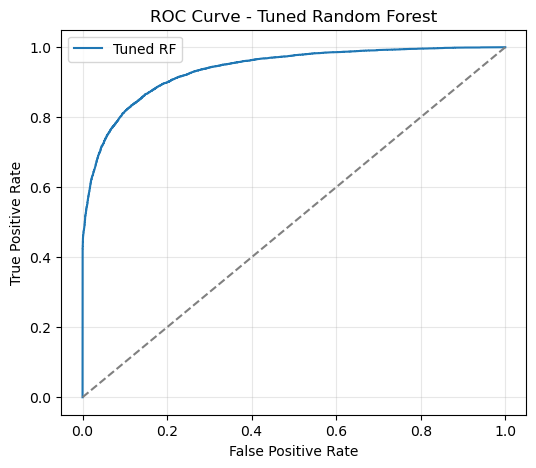

In [66]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Tuned RF')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


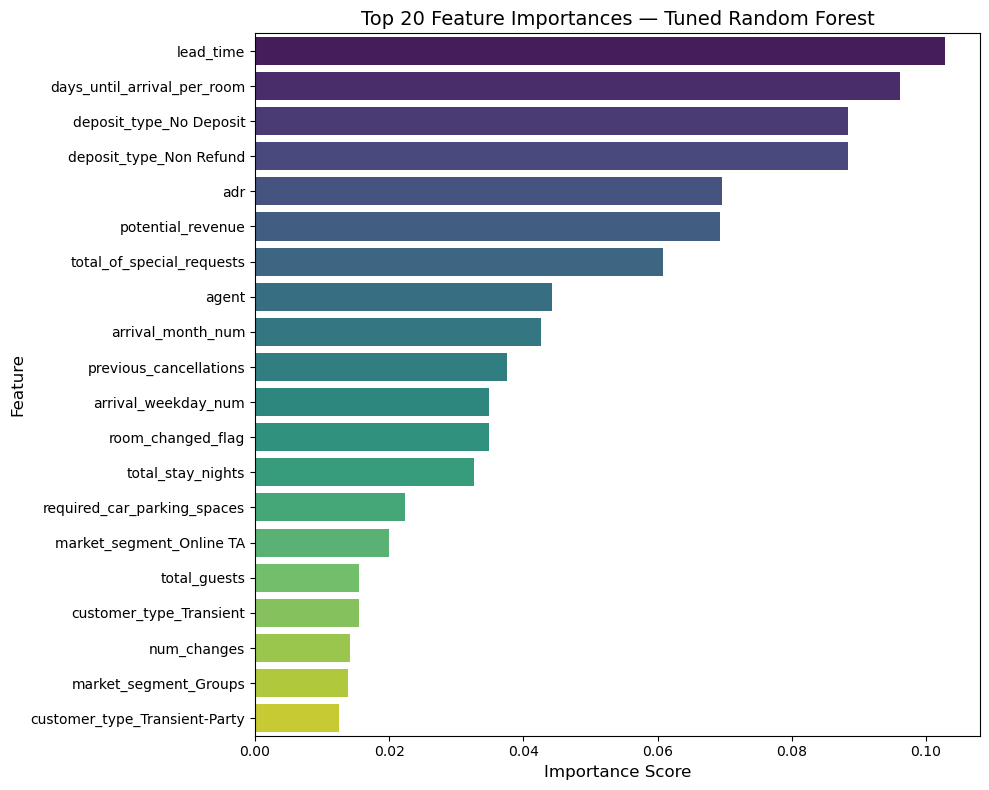

In [71]:
feature_names = list(numeric_cols) + list(encoded_feature_names)

# Extract feature importances from tuned model
importances = best_rf.feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

#  Plot Top 20 Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(
    x=feat_imp_df['importance'].head(20),
    y=feat_imp_df['feature'].head(20),
    palette="viridis"
)
plt.title("Top 20 Feature Importances — Tuned Random Forest", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()


### Tuned Random Forest Results
The tuned Random Forest model performed really well, reaching around 87% accuracy and a ROC-AUC of 0.94. It’s able to catch most cancellations while still keeping false alarms low, making it a reliable choice for predicting booking behavior.
Feature importance results highlight lead_time, days_until_arrival_per_room and deposit_type as the most influential predictors of cancellation. These factors indicate that flexible, last-minute bookings carry the highest cancellation risk and should be monitored closely.

## Business Insights & Deployment

### Strongest Predictors of Booking Cancellation
Based on the Random Forest feature importance results, the most influential predictors of cancellation are:
1. Lead Time
- Meaning: Number of days between booking and arrival.
- Business insight: Bookings made far in advance are less likely to cancel, while last-minute bookings show higher cancellation risk.
2. Deposit Type
- Meaning: Whether the booking is “No Deposit”, “Non-Refund”, etc.
- Business insight: No-deposit bookings cancel more often because customers have no financial commitment. Non-refundable bookings have the lowest cancellation rates.
3. Days Until Arrival Per Room
- Meaning: A feature capturing booking timing relative to room price.
- Business insight: Expensive last-minute bookings tend to cancel more frequently; early, lower-rate bookings are more stable.
4. ADR / Potential Revenue
- Meaning: Price of the room (ADR) and total expected revenue.
- Business insight: High-value bookings behave differently. Some high-ADR bookings cancel more due to flexible booking behavior, while lower ADR bookings tend to be more committed.
5. Previous Cancellations
- Meaning: Number of times a guest cancelled earlier.
- Business insight: Guests who have cancelled before are more likely to cancel again.
6. Total Special Requests
- Meaning: Number of requests (baby bed, view, early check-in, etc.)
- Business insight: Guests with more special requests often show more intent and usually do not cancel.

## Scenario Analysis
Suppose the hotel wants to reduce cancellation by overbooking 5% of total booked rooms. Use your model to estimate how many additional bookings they should accept, considering predicted cancellation probabilities.

In [74]:

# 1. cancellation probability for X_test_Final data
probs = best_rf.predict_proba(X_test_final)[:, 1]  
# probs = array like: [0.02, 0.55, 0.10, 0.80, ...]

# 2. Count how many bookings we have
n_bookings = len(probs)

# 3. Calculate 5% extra
extra_target = int(np.ceil(n_bookings * 0.05))
print("We should accept this many extra bookings:", extra_target)

# 4. Put probabilities into a dataframe
df = pd.DataFrame({'prob_cancel': probs})

# 5. Sort ascending → lowest risk first
df_sorted = df.sort_values('prob_cancel')

# 6. Pick the first 5% (safest customers)
safe_overbook = df_sorted.head(extra_target)

print("\nAverage cancellation probability of extra bookings:",
      safe_overbook['prob_cancel'].mean())

safe_overbook.head(15)



We should accept this many extra bookings: 1194

Average cancellation probability of extra bookings: 0.0004088627457748489


,prob_cancel
17118,0.0
2751,0.0
2749,0.0
13023,0.0
2745,0.0
2742,0.0
13026,0.0
13028,0.0
18699,0.0
13042,0.0


## Model Fairness / Bias Analysis: 
Check if cancellation rates differ significantly between hotel types (Resort vs City) or across market_segment. Evaluate whether your model is biased and suggest mitigation (e.g., oversampling, fairness constraints).


In [75]:
## Preparing the evaluation dataframe
df_eval = X_test.copy()   # original categorical values
df_eval['y_true'] = y_test.values
df_eval['y_pred'] = y_pred_best
df_eval['y_prob'] = y_prob_best


In [76]:
## Checking cancellation rates by HOTEL type
df_eval.groupby('hotel')['y_true'].mean()

hotel
City Hotel      0.424135
Resort Hotel    0.266445
Name: y_true, dtype: float64

In [78]:
## Checking model precision & recall by hotel type

for h, sub in df_eval.groupby('hotel'):
    p = precision_score(sub['y_true'], sub['y_pred'])
    r = recall_score(sub['y_true'], sub['y_pred'])
    print(h, "Precision:", round(p,3), "Recall:", round(r,3), "n=", len(sub))


City Hotel Precision: 0.893 Recall: 0.788 n= 15745
Resort Hotel Precision: 0.8 Recall: 0.696 n= 8133


In [79]:
## Check cancellation rates by MARKET SEGMENT
df_eval.groupby('market_segment')['y_true'].mean().sort_values(ascending=False)


market_segment
Groups           0.610667
Online TA        0.370949
Offline TA/TO    0.344813
Aviation         0.200000
Corporate        0.187675
Direct           0.152149
Complementary    0.107143
Name: y_true, dtype: float64

In [80]:
## Chi-square test
import scipy.stats as stats

ct = pd.crosstab(df_eval['hotel'], df_eval['y_true'])
chi2, p, dof, ex = stats.chi2_contingency(ct)
print("Hotel Type Chi-square p-value:", p)


Hotel Type Chi-square p-value: 3.1802748177629676e-126


## Summary 
1. Hotel Type (Cancellation Rates)
- City Hotel guests cancel more (42.4%) than Resort Hotel guests (26.6%).
- This difference is statistically significant, meaning the two hotel types naturally behave differently.
2. Model Performance by Hotel Type 
- The model performs well for both types (Precision: City 0.89, Resort 0.80; Recall: City 0.78, Resort 0.69).
- The model shows small performance differences across hotel types but nothing severe enough to call it biased.
3. Market Segment
- Cancellation rates differ: Groups (61%), Online TA (37%), Offline TA/TO (34%) cancel the most.
- Corporate (18%) and Direct (15%) cancel the least — this is normal customer behavior, not model bias.
Overall, the model does not show strong bias, but performance should be monitored across groups.

In [81]:
##------------------------- The End -------------------------------------